<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Atmospheric Neutrino Analysis 2 — Earth Density Tomography via Neutrino Regeneration
---

Connects the *layered* structure of the Earth electron-density model (the
shell boundaries in `earth_density.csv`) to visible kinks in the
Earth-regeneration probability as a function of nadir angle, showing that the
neutrino propagation code is directly sensitive to the internal density
profile of the Earth.

| Section | Topic |
|---------|-------|
| 1 | Libraries |
| 2 | Configuration (parameters · shared objects · helpers) |
| 3 | Layered Earth Density Profile |
| 4 | Critical Nadir Angles at Shell Boundaries |
| 5 | Regeneration Probability vs Nadir Angle |
| 6 | Kink Detection via Numerical Derivative |
| 7 | Summary |

## 1. Libraries

In [1]:
from __future__ import annotations

import math
import matplotlib.pyplot as plt
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config

from tpeanuts.util.notebooks import save_and_show
from tpeanuts.util.type import to_numpy
from tpeanuts.util.context import RuntimeContext

from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state


print(f"Torch version : {torch.__version__}")


Torch version : 2.3.1


## 2. Configuration

### 2.1 Paths

In [2]:
config = load_notebook_config()

OUTPUT_ROOT = config.output_root
OUTPUT_DIR = config.output_dir("results", "4_earth_tomography")

EARTH_DENSITY_FILE = str(config.earth_density_file)


print("Output directory:", OUTPUT_DIR)


Output directory: v:\output\results\4_earth_tomography


### 2.2 Parameters

`MASS_WEIGHTS` is an arbitrary incoherent mass-eigenstate mixture used to probe
the Earth propagation operator directly (the same pattern used in
`benchmark0_tpeanuts_vs_peanuts_precision.ipynb`, Section 5), so this notebook
isolates the Earth physics without depending on the solar production stage.

In [3]:
DEVICE = config.device
DTYPE = config.dtype
SHOW_PLOTS = config.show_plots
context = RuntimeContext.resolve(DEVICE, DTYPE)
oscillation = PropagationConfig.oscillation_parameters_from_preset(context=context, antinu=False)
pmns = oscillation.pmns
THETA12 = float(pmns.params.theta12.detach().cpu())
THETA13 = float(pmns.params.theta13.detach().cpu())
THETA23 = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.mass_spectrum.DeltamSq3l.detach().cpu())

DETECTOR_DEPTH_M = 0.0
PROBE_ENERGY_MEV = 8.0
TRAJECTORY_X_GRID = torch.linspace(0.0, 1.0, 600, dtype=DTYPE, device=DEVICE)
TOMOGRAPHY_PROBE_ETAS = [0.05, 0.30, 0.60, 1.00, 1.40]
TOMOGRAPHY_ETA_DENSE = torch.linspace(0.01, math.pi / 2.0 - 0.01, 400, dtype=DTYPE, device=DEVICE)

MASS_WEIGHTS = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)
FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]

print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")
print("Parameters loaded.")


Oscillation preset: _SM_NUFIT52_NO (NO)
Parameters loaded.


### 2.3 Shared Objects

In [4]:
earth_profile = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={"density_file": EARTH_DENSITY_FILE, "tabulated_density": False},
    ),
    context=context,
)
print(f"Shell radii rj (r/R_Earth): {to_numpy(earth_profile.rj)}")

Shell radii rj (r/R_Earth): [0.192 0.546 0.895 0.937 1.   ]


### 2.4 Helpers

For a trajectory at nadir angle $\eta$, shell $k$ (radius $r_j[k]$) is crossed
exactly when $r_j[k] > \sin\eta$ (`EarthProfile.shells_x`); equivalently, the
*critical* nadir angle at which the trajectory grazes shell $k$ is

$$
\eta_k = \arcsin\big(r_j[k]\big).
$$

For $\eta<\eta_k$ the trajectory crosses shell $k$; for $\eta>\eta_k$ it does
not — so the density profile (and its gradient) is discontinuous in $\eta$
exactly at each $\eta_k$.

In [5]:
def critical_etas():
    return torch.asin(torch.clamp(earth_profile.rj, max=1.0))

print("Helpers defined.")

Helpers defined.


## 3. Layered Earth Density Profile

The trajectory electron density $n_e(x,\eta)$ (`EarthProfile.call`) along the
dimensionless chord coordinate $x$, plotted for several nadir angles.
**Expected result:** step-like jumps in $n_e(x)$ at the radii where the
trajectory crosses a shell boundary, with deeper trajectories (smaller
$\eta$) reaching the highest (core) densities.

Saved figure: v:\output\results\4_earth_tomography\earth_density_profile.png


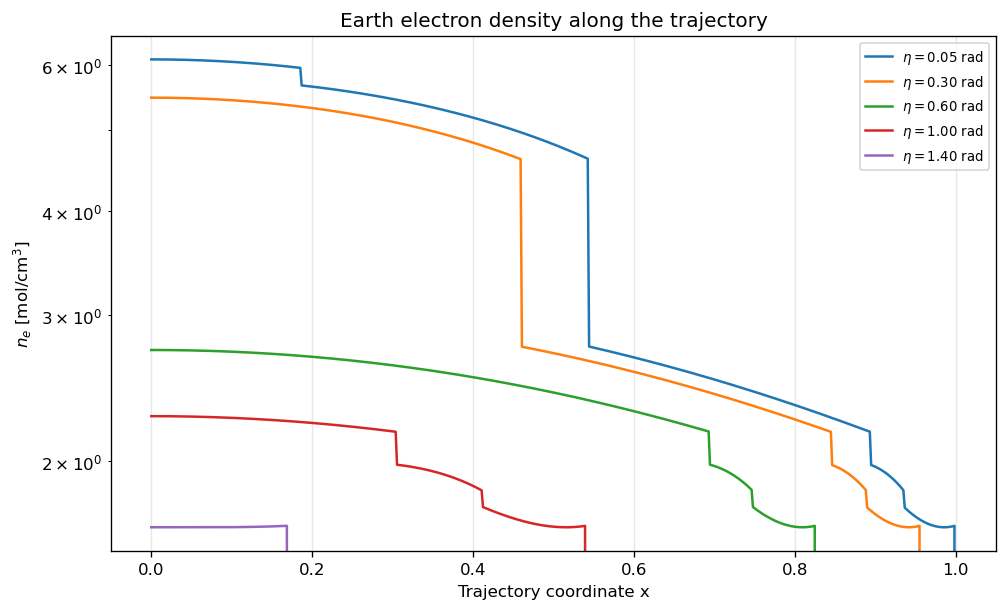

WindowsPath('v:/output/results/4_earth_tomography/earth_density_profile.png')

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for eta_val in TOMOGRAPHY_PROBE_ETAS:
    eta_t = torch.full_like(TRAJECTORY_X_GRID, eta_val)
    ne_curve = earth_profile.call(TRAJECTORY_X_GRID, eta_t)
    ax.plot(to_numpy(TRAJECTORY_X_GRID), to_numpy(ne_curve), label=rf"$\eta={eta_val:.2f}$ rad")
ax.set_yscale("log")
ax.set_xlabel("Trajectory coordinate x")
ax.set_ylabel(r"$n_e$ [mol/cm$^3$]")
ax.set_title("Earth electron density along the trajectory")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("earth_density_profile.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 4. Critical Nadir Angles at Shell Boundaries

**Expected result:** one critical angle $\eta_k=\arcsin(r_j[k])$ per shell,
ordered from the innermost (core, smallest $r_j$, *largest* $\eta_k$ is
*not* implied -- smaller shells graze at smaller angles) to the outermost
(surface, $r_j\to1$, $\eta_k\to\pi/2$).

In [7]:
eta_k = critical_etas()
print(f"{'shell':>5s}  {'r_j':>8s}  {'eta_k [rad]':>12s}  {'eta_k [deg]':>12s}")
for k, (rj, ek) in enumerate(zip(to_numpy(earth_profile.rj), to_numpy(eta_k))):
    print(f"{k:5d}  {rj:8.4f}  {ek:12.4f}  {math.degrees(ek):12.2f}")

shell       r_j   eta_k [rad]   eta_k [deg]
    0    0.1920        0.1932         11.07
    1    0.5460        0.5776         33.09
    2    0.8950        1.1084         63.51
    3    0.9370        1.2139         69.55
    4    1.0000        1.5708         90.00


## 5. Regeneration Probability vs Nadir Angle

$P_e(\eta)$ for the incoherent mass mixture `MASS_WEIGHTS` propagated through
Earth at fixed energy, with the critical angles from Section 4 overlaid as
vertical dashed lines. **Expected result:** visible slope changes ("kinks") in
$P_e(\eta)$ exactly at the dashed lines, since the density profile crossed by
the trajectory (and hence the accumulated matter potential) changes character
at each shell boundary.

Saved figure: v:\output\results\4_earth_tomography\regeneration_vs_eta.png


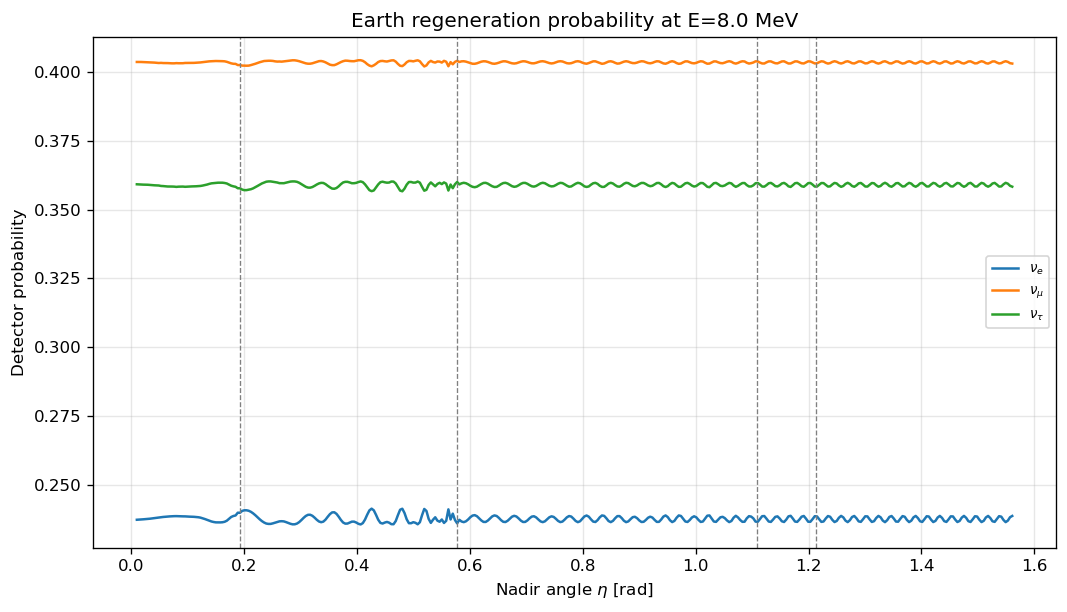

WindowsPath('v:/output/results/4_earth_tomography/regeneration_vs_eta.png')

In [8]:
P_eta = earth_probability_state(
    MASS_WEIGHTS, earth_profile, oscillation,
    torch.as_tensor(PROBE_ENERGY_MEV, dtype=DTYPE), TOMOGRAPHY_ETA_DENSE,
    DETECTOR_DEPTH_M, method="analytical", massbasis=True,
    context=context,
)

fig, ax = plt.subplots(figsize=(9.0, 5.2))
for i, lbl in enumerate(FLAVOUR_LABELS):
    ax.plot(to_numpy(TOMOGRAPHY_ETA_DENSE), to_numpy(P_eta[:, i]), label=lbl)
for ek in to_numpy(eta_k):
    if ek <= float(TOMOGRAPHY_ETA_DENSE.max()):
        ax.axvline(ek, color="gray", lw=0.8, ls="--")
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel("Detector probability")
ax.set_title(f"Earth regeneration probability at E={PROBE_ENERGY_MEV:.1f} MeV")
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("regeneration_vs_eta.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Kink Detection via Numerical Derivative

Taking the numerical derivative $dP_e/d\eta$ sharpens the kinks from Section 5
into visible peaks. **Expected result:** the peaks of $|dP_e/d\eta|$ line up
with the dashed critical-angle markers, confirming quantitatively that the
model's output is sensitive to the Earth's internal layered structure rather
than to a smooth, featureless density law.

Saved figure: v:\output\results\4_earth_tomography\regeneration_derivative.png


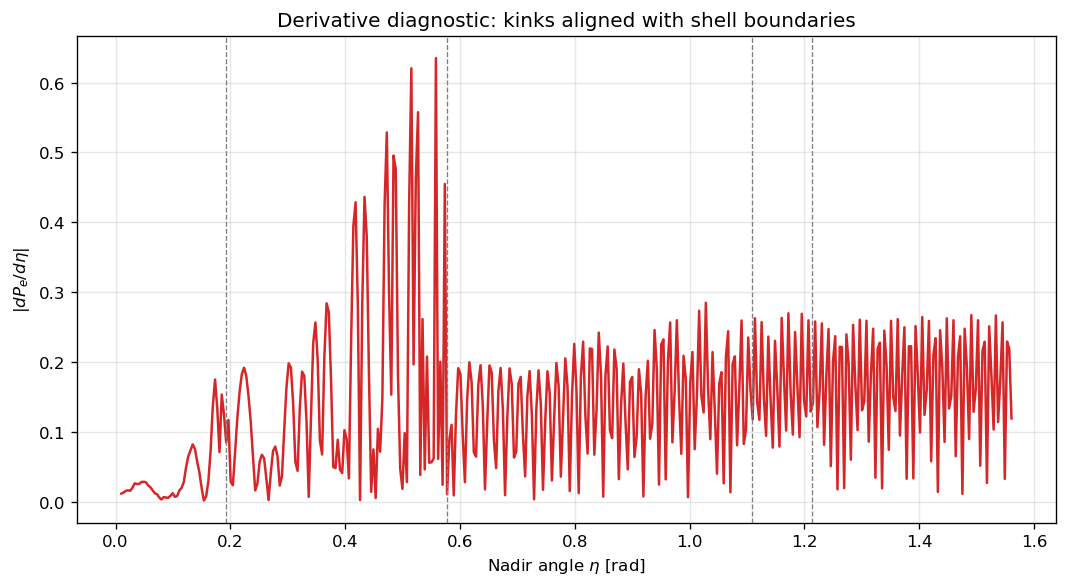

WindowsPath('v:/output/results/4_earth_tomography/regeneration_derivative.png')

In [9]:
dP_deta = torch.gradient(P_eta[:, 0], spacing=(TOMOGRAPHY_ETA_DENSE,))[0]

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(to_numpy(TOMOGRAPHY_ETA_DENSE), to_numpy(dP_deta.abs()), color="C3")
for ek in to_numpy(eta_k):
    if ek <= float(TOMOGRAPHY_ETA_DENSE.max()):
        ax.axvline(ek, color="gray", lw=0.8, ls="--")
ax.set_xlabel(r"Nadir angle $\eta$ [rad]")
ax.set_ylabel(r"$|dP_e/d\eta|$")
ax.set_title("Derivative diagnostic: kinks aligned with shell boundaries")
fig.tight_layout()
save_and_show("regeneration_derivative.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 7. Summary

In [10]:
print("Summary -- Earth density tomography")
print("-" * 60)
print(f"Number of density shells : {earth_profile.rj.numel()}")
print(f"Critical nadir angles [deg]: {[round(math.degrees(e), 2) for e in to_numpy(eta_k)]}")
print(f"P_e range over eta grid    : [{float(P_eta[:, 0].min()):.4f}, {float(P_eta[:, 0].max()):.4f}]")

Summary -- Earth density tomography
------------------------------------------------------------
Number of density shells : 5
Critical nadir angles [deg]: [11.07, 33.09, 63.51, 69.55, 90.0]
P_e range over eta grid    : [0.2355, 0.2412]
